# Robust modulated-coupling iSWAP — Cubic splines (v7)

Robust optimized pulse vs. Gaussian square default.
- Default: Gaussian-filtered square at 10 MHz g_eff, B3dB = 250 MHz, duration swept for iSWAP.
- Fidelity metric: free-phase fidelity with phases fixed from ε = 0.
- Error sweep: ZI, IZ, ZZ perturbations.

In [59]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt", "FFTW"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [60]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie
using FFTW

## Physical parameters and operators

In [61]:
δ12 = 2π * 0.1

XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

U_goal = exp(-im * π/4 * (XX + YY))

a_bound = 2π * 0.01
drive_bounds = fill(a_bound, 5)

println("δ₁₂ = ", round(δ12/(2π), digits=4), " GHz")
println("drive bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")

δ₁₂ = 0.1 GHz
drive bound = 10.0 MHz


## Hamiltonian and VariationalQuantumSystem

In [62]:
function H_nonlocal(u, t)
    g, uX1, uY1, uX2, uY2 = u
    return (
        δ12/2 * IZ
        + g * ((XX + YY) * cos(δ12 * t) + (YX - XY) * sin(δ12 * t))
        + uX1 * XI + uY1 * YI
        + uX2 * IX + uY2 * IY
    )
end

H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_nonlocal, H_vars, 5, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels, "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars), "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 5  n_vars = 3  time_dep = true


## Robust optimization — CubicSplinePulse

In [63]:
Random.seed!(42)
n_samples = 300
T_f       = 100.0
N_knots   = 15
Δt        = T_f / N_knots

controls = 2 .* a_bound .* rand(5, n_samples) .- a_bound
times    = collect(LinRange(0.0, T_f, n_samples))

du_init = zeros(5, n_samples)
pulse   = CubicSplinePulse(controls, du_init, times)

qcp = VariationalSplinePulseProblem(
    varsys, pulse, U_goal, N_knots;
    Q                     = 0.0,
    Q_r                   = 100.0,
    R                     = 1e-3,
    du_bound              = a_bound * 3,
    Δt_bounds             = (0.5Δt, 10Δt),
    dynamics_spline_order = 3,
    n_path_samples        = 3,
    piccolo_options       = PiccoloOptions(
        timesteps_all_equal = true,
        verbose             = true,
    ),
)

push!(qcp.prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, 0.9999, get_trajectory(qcp))
)

println("\nTrajectory components: ", keys(get_trajectory(qcp).components))

    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{DataInterpolations.CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 3
      added augmented state :var_Ũ⃗  dim=128  (3 error channels)
      dynamics spline order: 3
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

Trajectory components: (:Ũ⃗, :Δt, :t, :u, :du, :var_Ũ⃗)


In [64]:
let
    traj    = get_trajectory(qcp)
    us      = traj[:u]
    ts      = vec(traj[:t])
    iso_dim = traj.dims[:Ũ⃗]

    nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent=true)
    nlp_pulse   = LinearSplinePulse(us, ts)
    nlp_qtraj   = UnitaryTrajectory(nominal_sys, nlp_pulse, U_goal)

    Ũ⃗_init = hcat([operator_to_iso_vec(nlp_qtraj(t)) for t in ts]...)

    traj.data[traj.components[:Ũ⃗], :] .= Ũ⃗_init
    rows_var = traj.components[:var_Ũ⃗]
    traj.data[rows_var[1:iso_dim], :] .= Ũ⃗_init

    U_init = iso_vec_to_operator(Ũ⃗_init[:, end])
    F0 = abs2(tr(U_goal' * U_init)) / varsys.levels^2
    @printf("Initial fidelity (NLP-consistent init): %.4f\n", F0)
end

Initial fidelity (NLP-consistent init): 0.0483


In [65]:
log_path = joinpath(pwd(), "ipopt_cubic_robust_v6.log")
rm(log_path; force = true)

solve!(qcp;
    max_iter = 20,
    options  = IpoptOptions(eval_hessian = false, output_file = log_path),
)

if isfile(log_path)
    lines = readlines(log_path)
    print(join(lines[max(1, end-30):end], "\n"))
end

    initializing optimizer...
      building evaluator: 2 integrators, 2 nonlinear constraints
      dynamics constraints: 2240, nonlinear constraints: 421
        integrator 1 jacobian structure: 0.001s
        integrator 2 jacobian structure: 0.018s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.002s
        constraint 2 (NonlinearKnotPointConstraint) jacobian structure: 0.001s
      jacobian structure: 776052 nonzeros (0.027s)
        integrator 1 hessian structure: 0.042s
        integrator 2 hessian structure: 0.253s
        constraint 1 (CubicHermitePathConstraint) hessian structure: 0.004s
        constraint 2 (NonlinearKnotPointConstraint) hessian structure: 0.003s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.0s
          sub-objective 3 (QuadraticRegularizer): 0.0s
          sub-objective 4 (KnotPointObjective): 0.0s
       

## Default — Gaussian square pulse

Gaussian-filtered square at g_eff = 10 MHz (a_bound), smoothed by a 250 MHz 3dB
Gaussian low-pass filter. Flat-top width swept so that the coupling area
∫g(t)dt = π/4 (exact iSWAP in the interaction frame). No local drives, no ZZ.

In [ ]:
# --- Gaussian low-pass filter (from expt_pulses, B3dB = 250 MHz) ---

function fftfreq_ns(Np::Int, dt_ns::Float64)
    df = 1.0 / (Np * dt_ns)
    return df .* [j <= Np ÷ 2 ? j : j - Np for j in 0:Np-1]
end

function gaussian_square_pulse(;
    width_ns::Float64,
    pre_ns::Float64 = 25.0,
    post_ns::Float64 = 25.0,
    dt_ns::Float64 = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64 = a_bound,
)
    total_ns = pre_ns + width_ns + post_ns
    Np = Int(round(total_ns / dt_ns))
    t_ns = collect((0:Np-1) .* dt_ns)

    u_raw = zeros(Float64, Np)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:min(i1, Np)] .= amp

    f_ns = fftfreq_ns(Np, dt_ns)
    σ_f = (B3dB_MHz / 1000.0) / sqrt(log(2.0))
    Gf = @. exp(-0.5 * (f_ns / σ_f)^2)

    u_gf = real.(ifft(Gf .* fft(u_raw)))
    mx = maximum(u_gf)
    mx > 0 && (u_gf .*= amp / mx)

    return t_ns, u_gf
end

# --- GS system: interaction frame, H = g·(XX+YY) ---

H_gs(u, t) = u[1] * (XX + YY)

gs_sys = QuantumSystem(H_gs, [a_bound]; time_dependent = true)

# --- Find optimal flat-top via ∫g(t)dt = π/4 ---

let target = π / 4, w_lo = 5.0, w_hi = 25.0
    for _ in 1:60
        w = (w_lo + w_hi) / 2
        t, g = gaussian_square_pulse(width_ns = w)
        sum(g) * (t[2] - t[1]) < target ? (w_lo = w) : (w_hi = w)
    end
    global W_opt = (w_lo + w_hi) / 2
end

# Generate GS pulse, build single-drive trajectory
t_gs_fine, g_gs_fine = gaussian_square_pulse(width_ns = W_opt)
T_gs = t_gs_fine[end]
dt_fine = t_gs_fine[2] - t_gs_fine[1]

N_gs = 300
ts_gs = collect(LinRange(0.0, T_gs, N_gs))
g_gs = [g_gs_fine[clamp(round(Int, t / dt_fine) + 1, 1, length(g_gs_fine))]
        for t in ts_gs]

ctrls_gs = reshape(g_gs, 1, N_gs)   # single drive
pulse_gs = LinearSplinePulse(ctrls_gs, ts_gs)

qtraj_gs = UnitaryTrajectory(gs_sys, pulse_gs, U_goal)
U_gs = qtraj_gs(T_gs)

F_gs = abs2(tr(U_goal' * U_gs)) / 4^2
M_gs = U_goal' * U_gs

area_gs = sum(g_gs_fine) * dt_fine
@printf("Optimal flat-top width: %.4f ns  (total pulse: %.1f ns)\n", W_opt, T_gs)
@printf("Coupling area ∫g dt = %.8f   (π/4 = %.8f)\n", area_gs, π / 4)
@printf("Fidelity: %.10f   (infidelity: %.2e)\n", F_gs, 1 - F_gs)
println("|diag(Ug†·U_gs)| = ", round.(abs.(diag(M_gs)), digits=6))

## Rollout fidelities

In [ ]:
traj = get_trajectory(qcp)
nominal_sys = QuantumSystem(H_nonlocal, drive_bounds; time_dependent = true)

# Robust: standard fidelity (no free phases)
F_robust = unitary_rollout_fidelity(traj, nominal_sys; interpolation = :cubic_hermite)

@printf("Robust  rollout fidelity: %.8f  (infidelity: %.2e)\n", F_robust, 1 - F_robust)
@printf("GS      fidelity:         %.8f  (infidelity: %.2e)\n", F_gs, 1 - F_gs)

## Spline control plots

Evaluate the cubic spline at fine resolution so the smooth curves are visible.

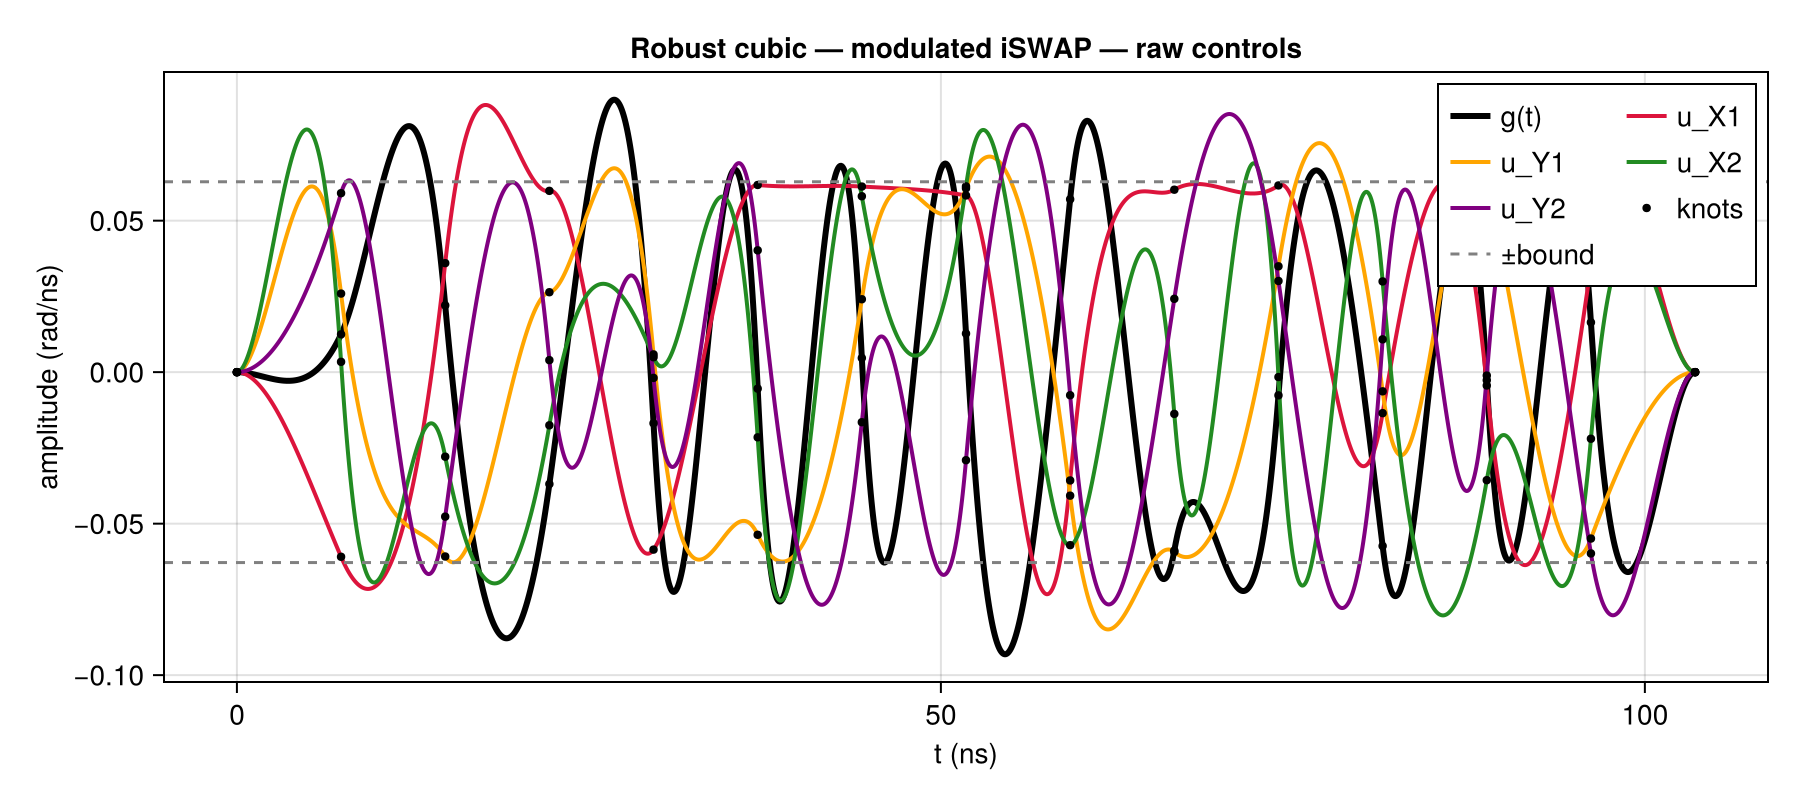

In [69]:
const KNOT_COLOR = :black
const KNOT_SIZE  = 6

function _spline_fine(traj)
    ts_knots = vec(traj[:t])
    us_knots = traj[:u]
    du_knots = traj[:du]
    pulse    = CubicSplinePulse(us_knots, du_knots, ts_knots)
    ts_fine  = collect(LinRange(ts_knots[1], ts_knots[end], 2000))
    us_fine  = sample(pulse, ts_fine)
    return ts_knots, us_knots, ts_fine, us_fine
end

function plot_raw_controls(traj, title_str)
    ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)

    labels = ["g(t)", "u_X1", "u_Y1", "u_X2", "u_Y2"]
    colors = [:black, :crimson, :orange, :forestgreen, :purple]
    widths = [3, 2, 2, 2, 2]

    fig = Figure(size = (900, 400))
    ax  = Axis(fig[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = title_str * " — raw controls",
    )
    for (i, (lbl, col, lw)) in enumerate(zip(labels, colors, widths))
        lines!(ax, ts_fine, vec(us_fine[i, :]); label = lbl, color = col, linewidth = lw)
    end
    for i in 1:5
        scatter!(ax, ts_knots, vec(us_knots[i, :]); color = KNOT_COLOR, markersize = KNOT_SIZE,
                 label = i == 1 ? "knots" : nothing)
    end
    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")
    axislegend(ax; position = :rt, nbanks = 2)
    return fig
end

function plot_modulated_controls(traj, title_str)
    ts_knots, us_knots, ts_fine, us_fine = _spline_fine(traj)
    colors = Makie.wong_colors()

    g_fine     = vec(us_fine[1, :])
    g_cos_fine = g_fine .* cos.(δ12 .* ts_fine)
    g_sin_fine = g_fine .* sin.(δ12 .* ts_fine)

    g_knot     = vec(us_knots[1, :])
    g_cos_knot = g_knot .* cos.(δ12 .* ts_knots)
    g_sin_knot = g_knot .* sin.(δ12 .* ts_knots)

    fig = Figure(size = (900, 400))
    ax  = Axis(fig[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = title_str * " — modulated",
    )

    lines!(ax, ts_fine, g_fine; label = "g_eff(t)", color = :black, linewidth = 3)
    scatter!(ax, ts_knots, g_knot; color = :black, markersize = KNOT_SIZE, label = "knots")

    lines!(ax, ts_fine, g_cos_fine; label = "g·cos(δ₁₂t)", color = :red,        linewidth = 2, linestyle = :dash)
    lines!(ax, ts_fine, g_sin_fine; label = "g·sin(δ₁₂t)", color = :dodgerblue, linewidth = 2, linestyle = :dash)

    local_labels = ["u_X1", "u_Y1", "u_X2", "u_Y2"]
    local_colors = [colors[3], colors[4], colors[5], colors[6]]
    for (j, (lbl, col)) in enumerate(zip(local_labels, local_colors))
        idx = j + 1
        lines!(ax, ts_fine, vec(us_fine[idx, :]); label = lbl, color = col, linewidth = 2)
        scatter!(ax, ts_knots, vec(us_knots[idx, :]); color = :black, markersize = KNOT_SIZE)
    end

    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")
    axislegend(ax; position = :rt, nbanks = 2)
    return fig
end

function plot_gs_controls(t_fine, g_fine, title_str)
    g_cos = g_fine .* cos.(δ12 .* t_fine)
    g_sin = g_fine .* sin.(δ12 .* t_fine)

    fig = Figure(size = (900, 400))
    ax  = Axis(fig[1, 1];
        xlabel = "t (ns)", ylabel = "amplitude (rad/ns)",
        title  = title_str,
    )

    lines!(ax, t_fine, g_fine; label = "g_eff(t)",    color = :black,      linewidth = 3)
    lines!(ax, t_fine, g_cos;  label = "g·cos(δ₁₂t)", color = :red,        linewidth = 2, linestyle = :dash)
    lines!(ax, t_fine, g_sin;  label = "g·sin(δ₁₂t)", color = :dodgerblue, linewidth = 2, linestyle = :dash)
    hlines!(ax, [a_bound, -a_bound]; linestyle = :dash, color = :gray, label = "±bound")

    axislegend(ax; position = :rt)
    return fig
end

plot_raw_controls(get_trajectory(qcp), "Robust cubic — modulated iSWAP")

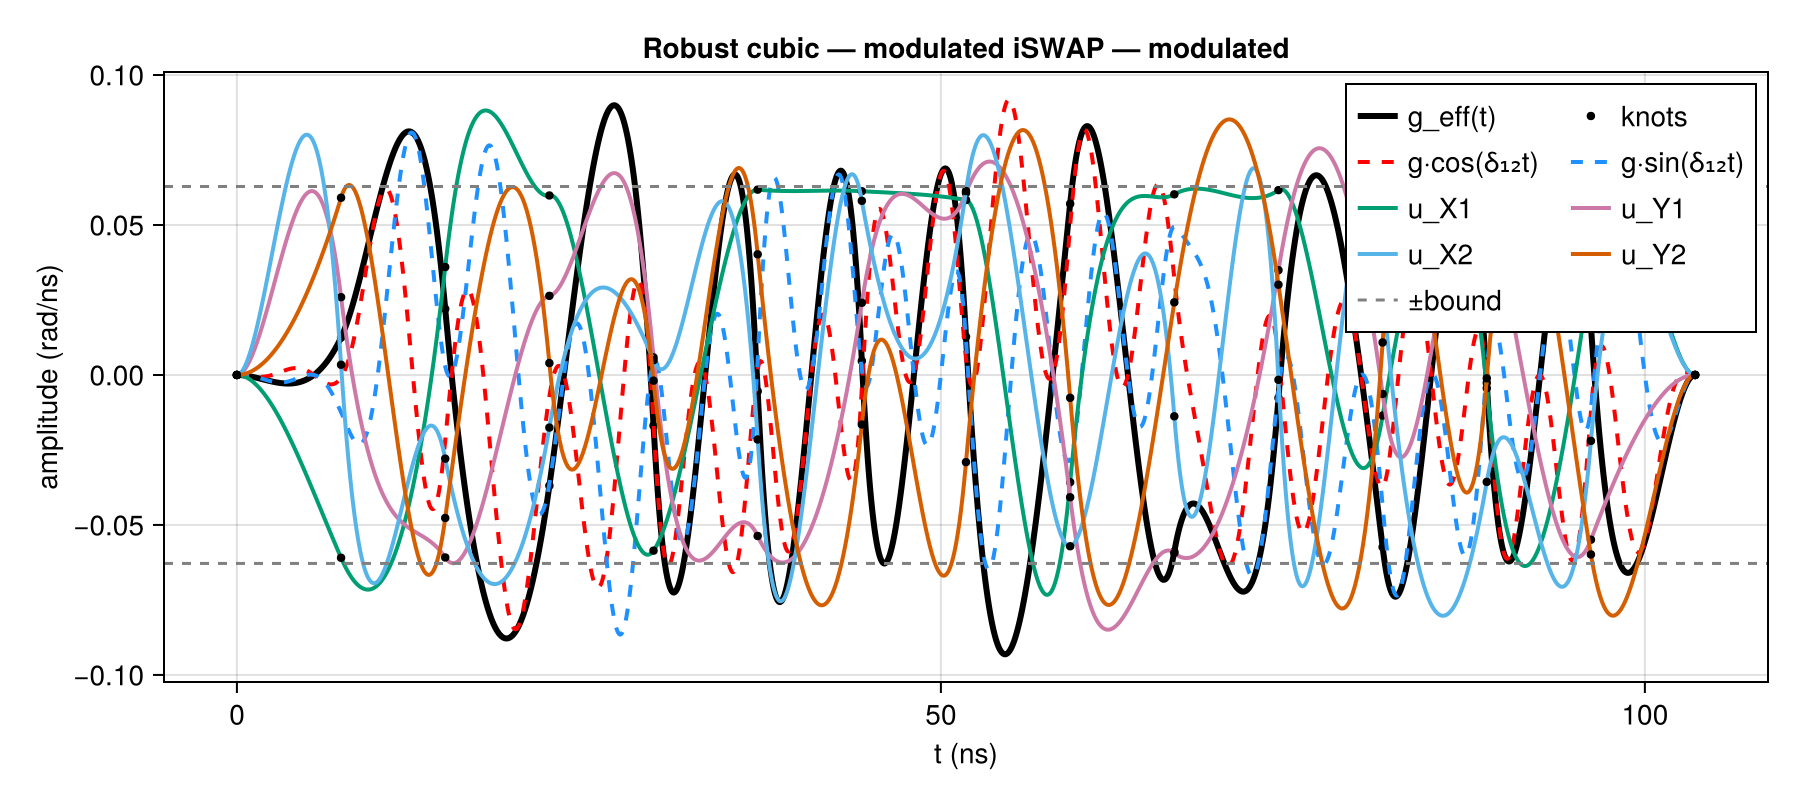

In [70]:
plot_modulated_controls(get_trajectory(qcp), "Robust cubic — modulated iSWAP")

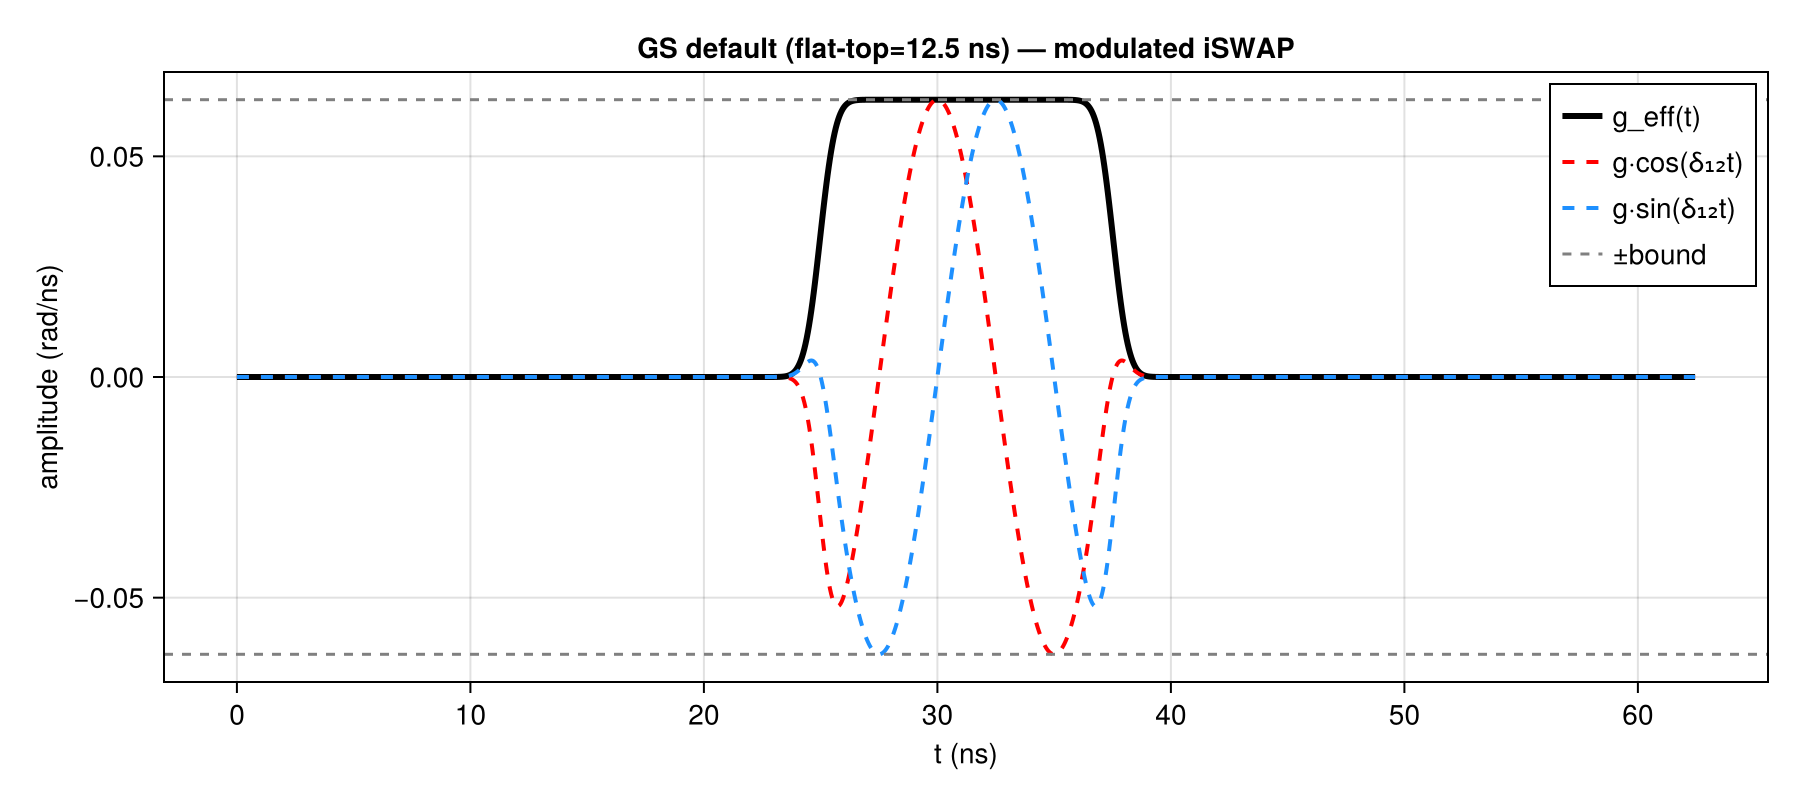

In [71]:
plot_gs_controls(collect(Float64, t_gs_fine), collect(Float64, g_gs_fine),
    @sprintf("GS default (flat-top=%.1f ns) — modulated iSWAP", W_opt))

## Fidelity vs. coherent error strength ε

In [ ]:
function make_perturbed_sys(ε, E)
    H_p = (u, t) -> H_nonlocal(u, t) + ε * E
    return QuantumSystem(H_p, drive_bounds; time_dependent = true)
end

function make_perturbed_gs_sys(ε, E)
    H_p = (u, t) -> u[1] * (XX + YY) + ε * E
    return QuantumSystem(H_p, [a_bound]; time_dependent = true)
end

error_channels = [ZI, IZ, ZZ]
error_labels   = ["ZI", "IZ", "ZZ"]
εs = collect(range(-0.05, 0.05, length = 51))

# Robust — standard fidelity via unitary_rollout_fidelity (no free phases)
fidelities_robust = [
    [unitary_rollout_fidelity(traj, make_perturbed_sys(ε, E);
        interpolation = :cubic_hermite) for ε in εs]
    for E in error_channels
]

# GS — interaction frame, no free phases
fidelities_gs = [
    [begin
        sys_p = make_perturbed_gs_sys(ε, E)
        qt_p  = UnitaryTrajectory(sys_p, pulse_gs, U_goal)
        U_p   = qt_p(T_gs)
        abs2(tr(U_goal' * U_p)) / 4^2
    end for ε in εs]
    for E in error_channels
]

@printf("ε=0  robust:  ZI=%.6f  IZ=%.6f  ZZ=%.6f\n",
    fidelities_robust[1][26], fidelities_robust[2][26], fidelities_robust[3][26])
@printf("ε=0  GS:      ZI=%.6f  IZ=%.6f  ZZ=%.6f\n",
    fidelities_gs[1][26], fidelities_gs[2][26], fidelities_gs[3][26])

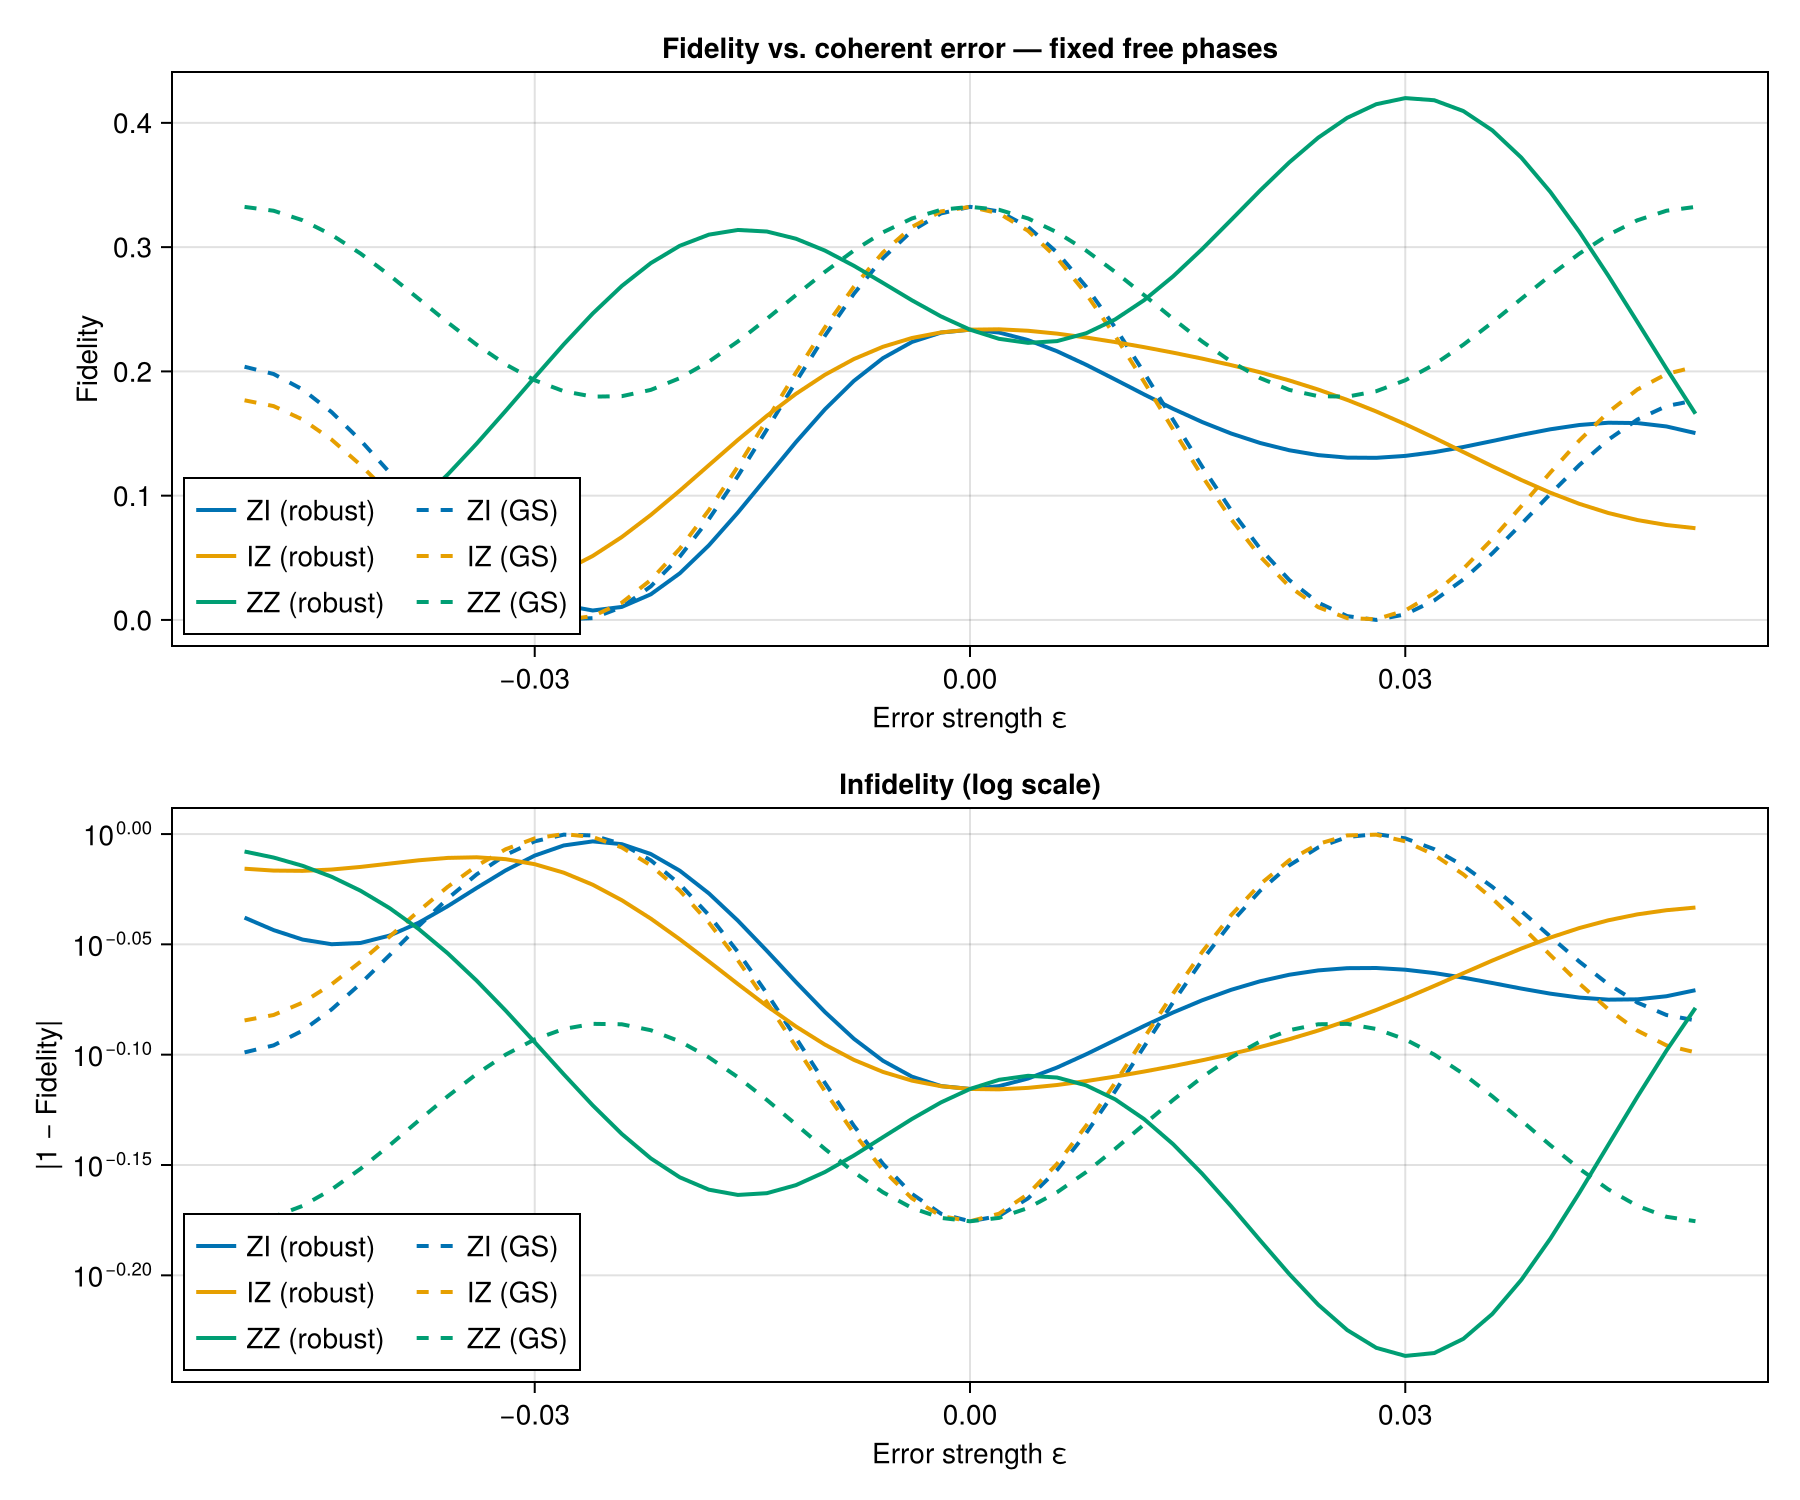

In [73]:
colors = Makie.wong_colors()

fig = Figure(size = (900, 750))

ax1 = Axis(fig[1, 1];
    xlabel = "Error strength ε",
    ylabel = "Fidelity",
    title  = "Fidelity vs. coherent error — fixed free phases",
)
for (i, (lbl, fs_r, fs_g)) in enumerate(zip(error_labels, fidelities_robust, fidelities_gs))
    lines!(ax1, εs, fs_r; label = "$lbl (robust)",  color = colors[i], linewidth = 2)
    lines!(ax1, εs, fs_g; label = "$lbl (GS)",      color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax1; position = :lb, nbanks = 2)

ax2 = Axis(fig[2, 1];
    xlabel = "Error strength ε",
    ylabel = "|1 − Fidelity|",
    title  = "Infidelity (log scale)",
    yscale = log10,
)
for (i, (lbl, fs_r, fs_g)) in enumerate(zip(error_labels, fidelities_robust, fidelities_gs))
    lines!(ax2, εs, max.(1 .- fs_r, 1e-16); label = "$lbl (robust)", color = colors[i], linewidth = 2)
    lines!(ax2, εs, max.(1 .- fs_g, 1e-16); label = "$lbl (GS)",     color = colors[i], linewidth = 2, linestyle = :dash)
end
axislegend(ax2; position = :lb, nbanks = 2)

fig